In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.21.0


In [4]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(x_train.shape)
print(y_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 8s 1us/step
(60000, 28, 28)
(60000,)


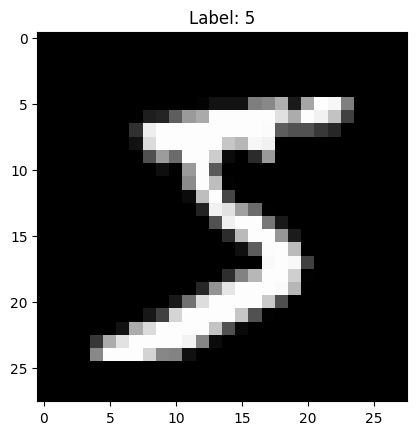

In [3]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [8]:
#normalization of data
x_train = x_train / 255.0
x_test = x_test / 255.0

print(x_train.min(), x_train.max())

0.0 1.0


In [9]:
#reshape data for CNN
import tensorflow as tf

x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [11]:
#build CNN model
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model1 = Sequential()
model1.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', input_shape=(28, 28, 1)))
model1.add(MaxPooling2D((2, 2)))
model1.add(Flatten())
model1.add(Dense(100, activation='relu', kernel_initializer='he_uniform'))
model1.add(Dense(10, activation='softmax'))

model1.summary()

/home/spoorthy_dayanand/miniconda3/envs/tfenv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1779426186.433804   51401 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       540,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 542,230 (2.07 MB)

 Trainable params: 542,230 (2.07 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
#optimizing model
from tensorflow.keras.optimizers import SGD

model1.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print(model1.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       540,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 542,230 (2.07 MB)

 Trainable params: 542,230 (2.07 MB)

 Non-trainable params: 0 (0.00 B)

None


In [15]:
#train model
history = model1.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9431 - loss: 0.1827 - val_accuracy: 0.9735 - val_loss: 0.0819
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9814 - loss: 0.0612 - val_accuracy: 0.9832 - val_loss: 0.0506
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9882 - loss: 0.0388 - val_accuracy: 0.9862 - val_loss: 0.0427
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9923 - loss: 0.0261 - val_accuracy: 0.9866 - val_loss: 0.0404
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9944 - loss: 0.0188 - val_accuracy: 0.9865 - val_loss: 0.0434


In [16]:
#testing image
import numpy as np

index = 0
image = x_test[index]

pred = model1.predict(image.reshape(1, 28, 28, 1))

print("Predicted label:", np.argmax(pred))
print("Actual label:", y_test[index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predicted label: 7
Actual label: 7


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


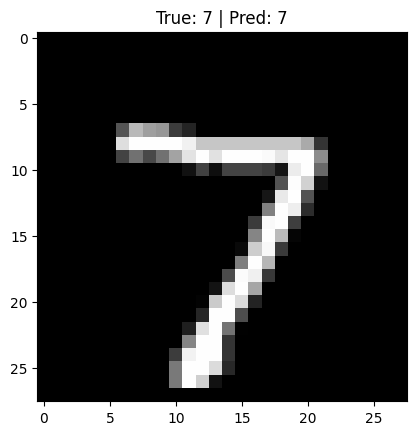

In [17]:
#visualize properly
import matplotlib.pyplot as plt
import numpy as np

index = 0

plt.imshow(x_test[index].reshape(28, 28), cmap='gray')
plt.title(f"True: {y_test[index]} | Pred: {np.argmax(model1.predict(x_test[index].reshape(1,28,28,1)))}")
plt.show()

In [19]:
#saving model
model1.save("mnist_cnn.keras")

In [20]:
#converting to tflite
import tensorflow as tf

model = tf.keras.models.load_model("mnist_cnn.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("mnist_cnn.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model saved!")

INFO:tensorflow:Assets written to: /tmp/tmponkkmx40/assets


INFO:tensorflow:Assets written to: /tmp/tmponkkmx40/assets


Saved artifact at '/tmp/tmponkkmx40'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  126944809500112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126944809489168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126944809497232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126944809500496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126944809493584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126944809497616: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1779427048.287482   51401 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1779427048.288878   51401 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


TFLite model saved!


I0000 00:00:1779427048.291952   51401 reader.cc:83] Reading SavedModel from: /tmp/tmponkkmx40
I0000 00:00:1779427048.292486   51401 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1779427048.292508   51401 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmponkkmx40
I0000 00:00:1779427048.308263   51401 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1779427048.309826   51401 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1779427048.350946   51401 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmponkkmx40
I0000 00:00:1779427048.359213   51401 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 67273 microseconds.
I0000 00:00:1779427048.479767   51401 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


In [21]:
#load tflite model
import tensorflow as tf
import numpy as np

interpreter = tf.lite.Interpreter(model_path="mnist_cnn.tflite")
interpreter.allocate_tensors()

print("TFLite model loaded successfully")

TFLite model loaded successfully


/home/spoorthy_dayanand/miniconda3/envs/tfenv/lib/python3.11/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [22]:
#get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(input_details)
print(output_details)

[{'name': 'serving_default_input_layer:0', 'index': 0, 'shape': array([ 1, 28, 28,  1], dtype=int32), 'shape_signature': array([-1, 28, 28,  1], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]
[{'name': 'StatefulPartitionedCall_1:0', 'index': 18, 'shape': array([ 1, 10], dtype=int32), 'shape_signature': array([-1, 10], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]


In [23]:
#pick one test image
index = 0
input_image = x_test[index].reshape(1, 28, 28, 1).astype(np.float32)

In [24]:
#run inference
interpreter.set_tensor(input_details[0]['index'], input_image)
interpreter.invoke()

output = interpreter.get_tensor(output_details[0]['index'])

print("Predicted digit:", np.argmax(output))
print("Actual digit:", y_test[index])

Predicted digit: 7
Actual digit: 7


In [25]:
#improving the CNN
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

/home/spoorthy_dayanand/miniconda3/envs/tfenv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


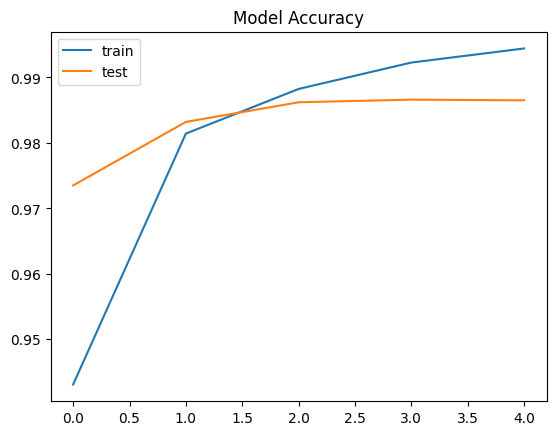

In [26]:
#training visualization
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['train','test'])
plt.show()

In [27]:
#error analysis
import numpy as np

preds = model1.predict(x_test)
pred_labels = np.argmax(preds, axis=1)

wrong = np.where(pred_labels != y_test)[0]

print("Misclassified samples:", len(wrong))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Misclassified samples: 135


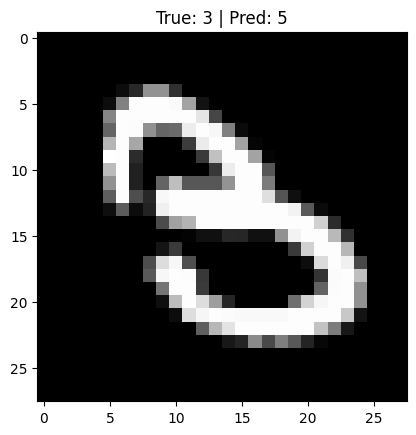

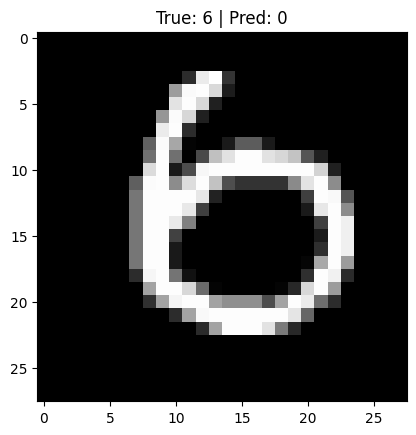

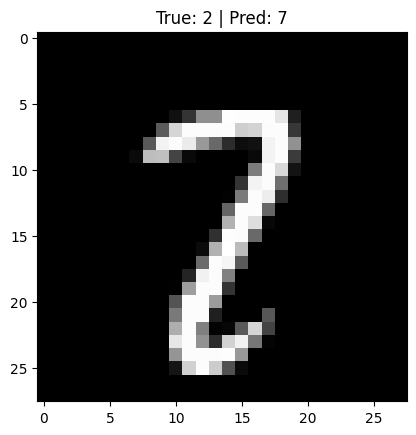

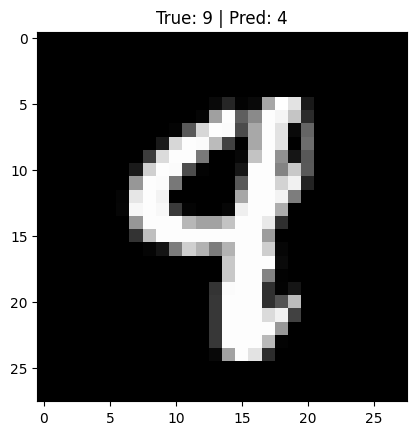

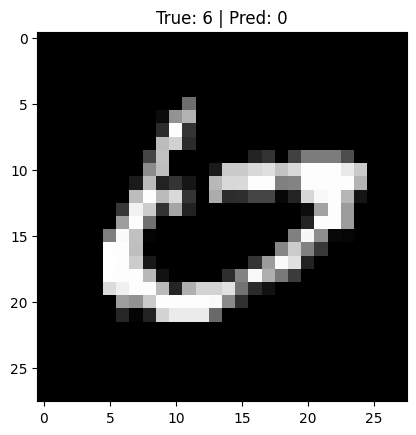

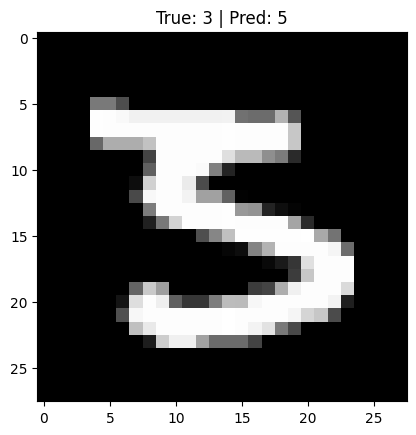

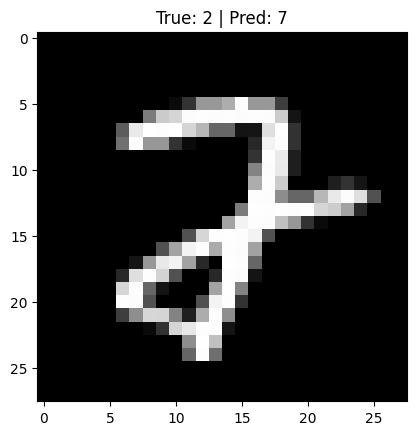

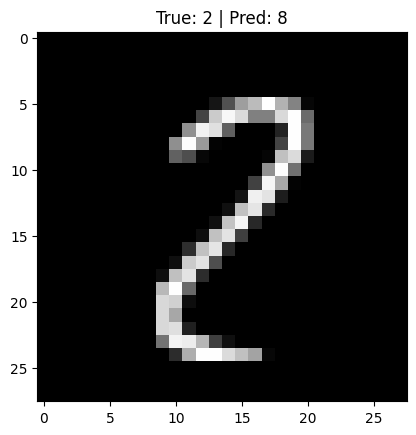

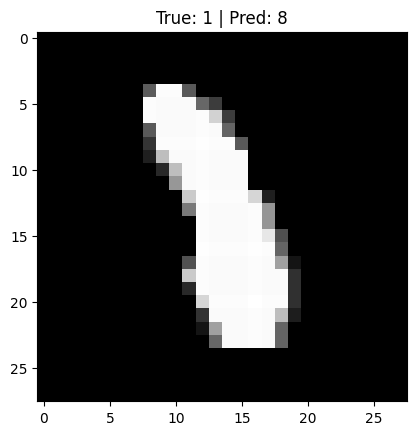

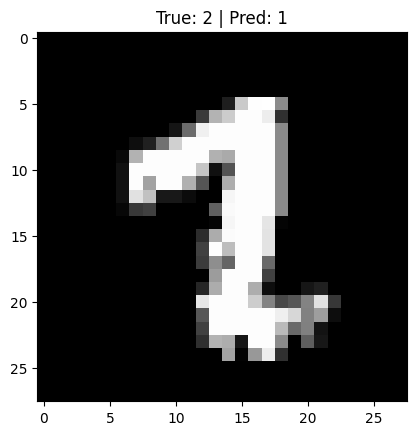

In [28]:
#visualize misclassified samples
import matplotlib.pyplot as plt
import numpy as np

for i in range(10):  # show first 10 wrong samples
    idx = wrong[i]
    plt.imshow(x_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"True: {y_test[idx]} | Pred: {pred_labels[idx]}")
    plt.show()

In [29]:
#count error patterns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_labels)
print(cm)

[[ 972    0    1    0    0    2    1    1    0    3]
 [   0 1128    1    1    0    2    0    1    2    0]
 [   3    1 1003    9    2    0    0    8    4    2]
 [   0    0    0  998    0    8    0    2    2    0]
 [   0    0    1    0  968    0    1    0    2   10]
 [   2    0    0    0    0  888    2    0    0    0]
 [   6    3    0    1    3    6  939    0    0    0]
 [   0    2    3    0    0    0    0 1020    1    2]
 [   4    0    0    0    0    2    0    1  956   11]
 [   0    1    0    2    5    2    0    6    0  993]]


In [30]:
#save model
model1.save("mnist_cnn.keras")

print("Model saved successfully!")

Model saved successfully!


In [31]:
#load model
from tensorflow.keras.models import load_model

loaded_model = load_model("mnist_cnn.keras")

print("Model loaded successfully!")

Model loaded successfully!


In [32]:
#inference using loaded model
import numpy as np

index = 0

test_image = x_test[index]

prediction = loaded_model.predict(
    test_image.reshape(1,28,28,1)
)

predicted_digit = np.argmax(prediction)

print("Predicted digit:", predicted_digit)
print("Actual digit:", y_test[index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
Predicted digit: 7
Actual digit: 7


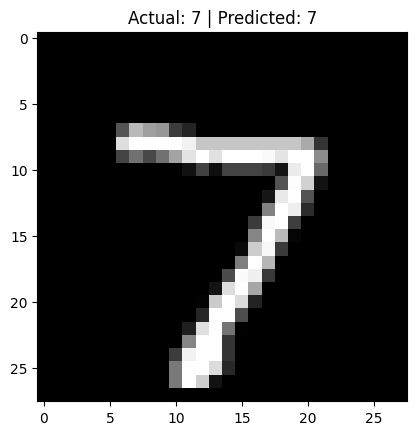

In [33]:
#visualize prediction
import matplotlib.pyplot as plt

plt.imshow(test_image.reshape(28,28), cmap='gray')

plt.title(
    f"Actual: {y_test[index]} | Predicted: {predicted_digit}"
)

plt.show()

In [35]:
#create tflite converter
converter = tf.lite.TFLiteConverter.from_keras_model(
    loaded_model
)

In [36]:
#convert to tflite
tflite_model = converter.convert()

INFO:tensorflow:Assets written to: /tmp/tmpdj_ukwn8/assets


INFO:tensorflow:Assets written to: /tmp/tmpdj_ukwn8/assets


Saved artifact at '/tmp/tmpdj_ukwn8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  126943077785744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126943077787280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126943077787088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126943077785552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126943077787856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126943077787472: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1779429459.848348   51401 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1779429459.850151   51401 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1779429459.853192   51401 reader.cc:83] Reading SavedModel from: /tmp/tmpdj_ukwn8
I0000 00:00:1779429459.853796   51401 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1779429459.853813   51401 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpdj_ukwn8
I0000 00:00:1779429459.860849   51401 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1779429459.934860   51401 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpdj_ukwn8
I0000 00:00:1779429459.942437   51401 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 89259 microseconds.


In [37]:
#load tflite model
interpreter = tf.lite.Interpreter(
    model_path="mnist_cnn.tflite"
)

interpreter.allocate_tensors()

print("TFLite model loaded successfully!")

TFLite model loaded successfully!


/home/spoorthy_dayanand/miniconda3/envs/tfenv/lib/python3.11/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [38]:
#fixed CNN model
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Conv2D(
        32, (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64, (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')
])

/home/spoorthy_dayanand/miniconda3/envs/tfenv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
#compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [40]:
#training
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.9586 - loss: 0.1361 - val_accuracy: 0.9844 - val_loss: 0.0492
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9865 - loss: 0.0439 - val_accuracy: 0.9888 - val_loss: 0.0330
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9902 - loss: 0.0309 - val_accuracy: 0.9874 - val_loss: 0.0393
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9928 - loss: 0.0225 - val_accuracy: 0.9843 - val_loss: 0.0488
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9944 - loss: 0.0173 - val_accuracy: 0.9896 - val_loss: 0.0314


In [41]:
#save final model
model.save("final_mnist.keras")

In [42]:
#load saved model
loaded_model = tf.keras.models.load_model(
    "final_mnist.keras"
)

In [43]:
#validate tf inference
import numpy as np

pred = loaded_model.predict(
    x_test[0].reshape(1,28,28,1)
)

print("Predicted:", np.argmax(pred))
print("Actual:", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
Predicted: 7
Actual: 7


In [44]:
#convert to tflite
converter = tf.lite.TFLiteConverter.from_keras_model(
    loaded_model
)

tflite_model = converter.convert()

with open("final_mnist.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model saved!")

INFO:tensorflow:Assets written to: /tmp/tmpg8wp8zcq/assets


INFO:tensorflow:Assets written to: /tmp/tmpg8wp8zcq/assets


Saved artifact at '/tmp/tmpg8wp8zcq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  126943071840080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126943071838736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126943071838928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126943071835472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126943071837584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126943071838352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126943071836816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126943071837008: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model saved!


W0000 00:00:1779436232.108508   51401 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1779436232.109715   51401 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1779436232.113599   51401 reader.cc:83] Reading SavedModel from: /tmp/tmpg8wp8zcq
I0000 00:00:1779436232.114264   51401 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1779436232.114279   51401 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpg8wp8zcq
I0000 00:00:1779436232.121775   51401 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1779436232.179131   51401 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpg8wp8zcq
I0000 00:00:1779436232.189568   51401 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 75982 microseconds.


In [45]:
#load tflite model
interpreter = tf.lite.Interpreter(
    model_path="final_mnist.tflite"
)

interpreter.allocate_tensors()

/home/spoorthy_dayanand/miniconda3/envs/tfenv/lib/python3.11/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [46]:
#allocate tensors
interpreter.allocate_tensors()

print("Tensors allocated successfully!")

Tensors allocated successfully!


In [47]:
#get input output details
input_details = interpreter.get_input_details()

output_details = interpreter.get_output_details()

print(input_details)
print(output_details)

[{'name': 'serving_default_input_layer_2:0', 'index': 0, 'shape': array([ 1, 28, 28,  1], dtype=int32), 'shape_signature': array([-1, 28, 28,  1], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]
[{'name': 'StatefulPartitionedCall_1:0', 'index': 22, 'shape': array([ 1, 10], dtype=int32), 'shape_signature': array([-1, 10], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]


In [48]:
#prepare test image
import numpy as np

input_image = x_test[0].reshape(
    1,28,28,1
).astype(np.float32)

print(input_image.shape)

(1, 28, 28, 1)


In [49]:
#feed image to tflite model
interpreter.set_tensor(
    input_details[0]['index'],
    input_image
)

In [50]:
#run inference
interpreter.invoke()

In [51]:
#get output prediction
output = interpreter.get_tensor(
    output_details[0]['index']
)

print(output)

[[2.97516178e-10 2.83908119e-10 1.76861352e-06 1.03434054e-07
  2.81263501e-09 9.44091055e-11 1.49030704e-13 9.99998093e-01
  1.16093790e-09 1.88648244e-08]]


In [52]:
#predicted digit
predicted_digit = np.argmax(output)

print("Predicted digit:", predicted_digit)

print("Actual digit:", y_test[0])

Predicted digit: 7
Actual digit: 7


In [53]:
#validate multiple images
for i in range(5):

    input_image = x_test[i].reshape(
        1,28,28,1
    ).astype(np.float32)

    interpreter.set_tensor(
        input_details[0]['index'],
        input_image
    )

    interpreter.invoke()

    output = interpreter.get_tensor(
        output_details[0]['index']
    )

    pred = np.argmax(output)

    print(
        f"Image {i} -> "
        f"Predicted: {pred}, "
        f"Actual: {y_test[i]}"
    )

Image 0 -> Predicted: 7, Actual: 7
Image 1 -> Predicted: 2, Actual: 2
Image 2 -> Predicted: 1, Actual: 1
Image 3 -> Predicted: 0, Actual: 0
Image 4 -> Predicted: 4, Actual: 4


In [54]:
#create INT8 quantized model
import tensorflow as tf
import numpy as np

# load saved keras model
loaded_model = tf.keras.models.load_model(
    "final_mnist.keras"
)

# representative dataset
def representative_data_gen():

    for i in range(100):

        image = x_train[i].reshape(
            1,28,28,1
        ).astype(np.float32)

        yield [image]

# converter
converter = tf.lite.TFLiteConverter.from_keras_model(
    loaded_model
)

# enable optimization
converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

# representative dataset
converter.representative_dataset = representative_data_gen

# force full integer quantization
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# convert
quant_model = converter.convert()

# save
with open(
    "MyMNISTModel_int8.tflite",
    "wb"
) as f:

    f.write(quant_model)

print("INT8 model generated successfully!")

INFO:tensorflow:Assets written to: /tmp/tmp821vuytc/assets


INFO:tensorflow:Assets written to: /tmp/tmp821vuytc/assets


Saved artifact at '/tmp/tmp821vuytc'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  126942748610000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126942748612112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126944849625168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126943071832016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126943071831440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126943071839504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126943071835280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126943071832400: TensorSpec(shape=(), dtype=tf.resource, name=None)


/home/spoorthy_dayanand/miniconda3/envs/tfenv/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1779436796.658472   51401 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1779436796.658875   51401 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1779436796.660392   51401 reader.cc:83] Reading SavedModel from: /tmp/tmp821vuytc
I0000 00:00:1779436796.662488   51401 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1779436796.662506   51401 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp821vuytc
I0000 00:00:1779436796.677188   51401 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1779436796.762839   51401 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp821vuytc
I0000 00:00:1779436796.773303   51401 loader.cc:471] SavedM

INT8 model generated successfully!


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1779436797.424162   51401 flatbuffer_export.cc:3851] Skipping runtime version metadata in the model. This will be generated by the exporter.
